In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

events = pd.read_parquet(
    PROCESSED_DIR / "nse_reversal_events_v1.parquet"
)

events = events.sort_values(["Date", "ticker"]).reset_index(drop=True)

print(events.shape)
events.head()

(15074, 14)


,Date,Adj Close,Close,High,Low,Open,Volume,ticker,company,sector,past_return_10d,future_return_5d,candidate_decline,reversal
0,2015-01-15,131.351776,141.899994,145.750000,138.350006,143.550003,10860317,HINDALCO.NS,Hindalco Industries,Materials,-0.104449,0.010923,True,0
1,2015-01-15,86.087814,97.095001,98.800003,95.665001,97.794998,6814340,JSWSTEEL.NS,JSW Steel,Materials,-0.089080,0.022967,True,0
2,2015-01-16,291.052704,308.996063,317.242554,305.616333,312.736267,9779165,BHARTIARTL.NS,Bharti Airtel,Telecom,-0.060814,0.120315,True,1
3,2015-01-16,2050.268799,2897.699951,2970.000000,2891.300049,2950.399902,441344,HEROMOTOCO.NS,Hero MotoCorp,Automobile,-0.064685,-0.012044,True,0
4,2015-01-16,128.250809,138.550003,143.399994,137.750000,141.500000,9096928,HINDALCO.NS,Hindalco Industries,Materials,-0.134603,0.045110,True,1


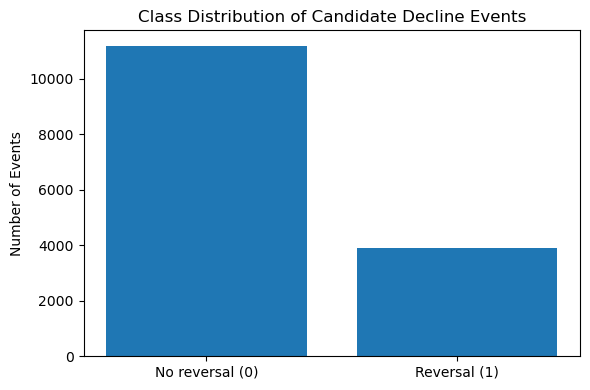

reversal
0    74.16
1    25.84
Name: percentage, dtype: float64


In [2]:
class_counts = events["reversal"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(
    ["No reversal (0)", "Reversal (1)"],
    class_counts.values
)
plt.title("Class Distribution of Candidate Decline Events")
plt.ylabel("Number of Events")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_distribution.png", dpi=150)
plt.show()

print(
    (class_counts / class_counts.sum() * 100)
    .round(2)
    .rename("percentage")
)

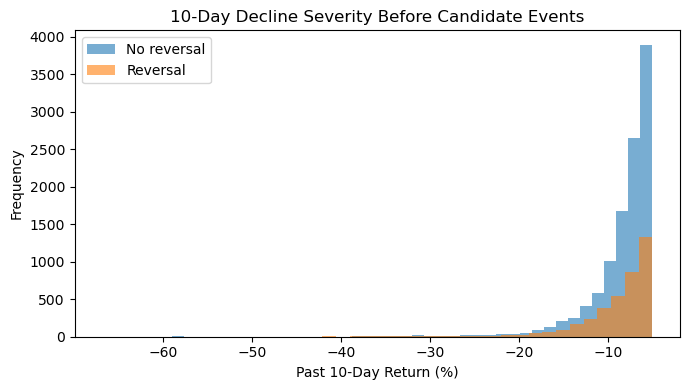

In [3]:
plt.figure(figsize=(7, 4))

for label, name in [(0, "No reversal"), (1, "Reversal")]:
    values = events.loc[
        events["reversal"] == label,
        "past_return_10d"
    ] * 100
    plt.hist(values, bins=40, alpha=0.6, label=name)

plt.title("10-Day Decline Severity Before Candidate Events")
plt.xlabel("Past 10-Day Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "past_return_by_class.png", dpi=150)
plt.show()

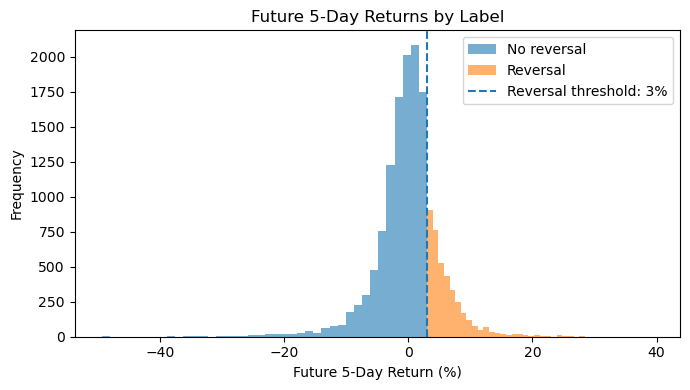

In [4]:
plt.figure(figsize=(7, 4))

for label, name in [(0, "No reversal"), (1, "Reversal")]:
    values = events.loc[
        events["reversal"] == label,
        "future_return_5d"
    ] * 100
    plt.hist(values, bins=40, alpha=0.6, label=name)

plt.axvline(3, linestyle="--", label="Reversal threshold: 3%")
plt.title("Future 5-Day Returns by Label")
plt.xlabel("Future 5-Day Return (%)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "future_return_by_class.png", dpi=150)
plt.show()

In [5]:
sector_summary = (
    events.groupby("sector")
    .agg(
        candidate_events=("reversal", "size"),
        reversals=("reversal", "sum"),
        reversal_rate=("reversal", "mean")
    )
    .sort_values("reversal_rate", ascending=False)
)

sector_summary["reversal_rate"] = (
    sector_summary["reversal_rate"] * 100
).round(2)

sector_summary

,candidate_events,reversals,reversal_rate
sector,,,
Materials,2423,715,29.51
Industrials,816,231,28.31
Automobile,1512,425,28.11
Energy,1164,322,27.66
Financial Services,2920,758,25.96
Healthcare,1768,458,25.90
Utilities,494,117,23.68
Consumer Staples,1306,299,22.89
Telecom,326,73,22.39


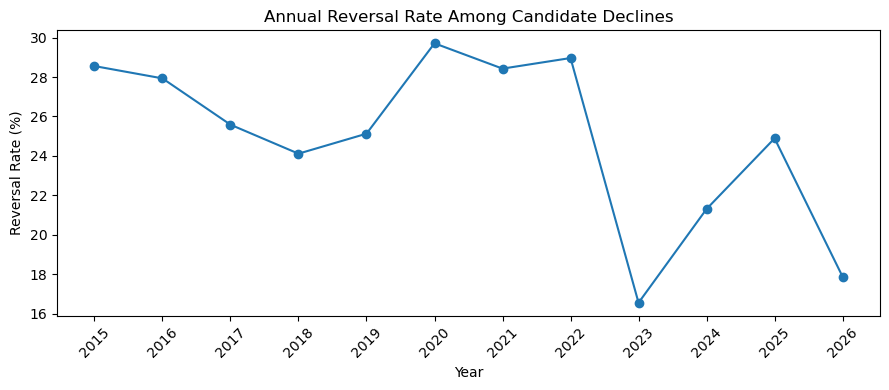

,candidate_events,reversal_rate
year,,
2015,1632,28.55
2016,1493,27.93
2017,727,25.58
2018,1501,24.12
2019,1357,25.13
2020,1875,29.71
2021,1263,28.42
2022,1578,28.96
2023,664,16.57


In [6]:
events["year"] = events["Date"].dt.year

yearly_summary = (
    events.groupby("year")
    .agg(
        candidate_events=("reversal", "size"),
        reversal_rate=("reversal", "mean")
    )
)

yearly_summary["reversal_rate"] = (
    yearly_summary["reversal_rate"] * 100
)

plt.figure(figsize=(9, 4))
plt.plot(
    yearly_summary.index,
    yearly_summary["reversal_rate"],
    marker="o"
)
plt.title("Annual Reversal Rate Among Candidate Declines")
plt.xlabel("Year")
plt.ylabel("Reversal Rate (%)")
plt.xticks(yearly_summary.index, rotation=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "yearly_reversal_rate.png", dpi=150)
plt.show()

yearly_summary.round(2)

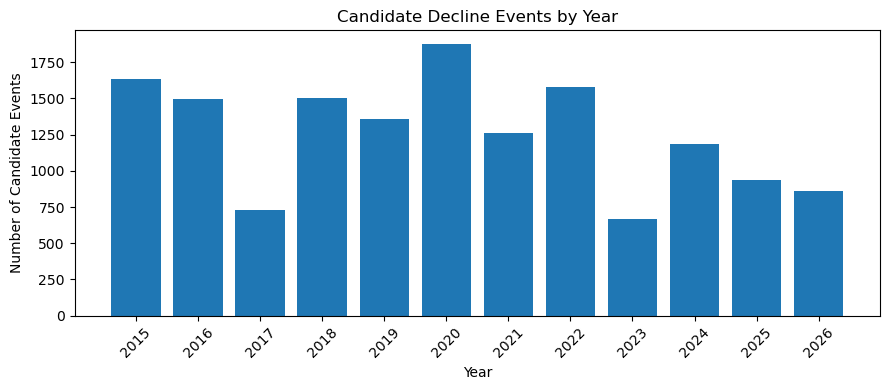

In [7]:
plt.figure(figsize=(9, 4))
plt.bar(
    yearly_summary.index,
    yearly_summary["candidate_events"]
)
plt.title("Candidate Decline Events by Year")
plt.xlabel("Year")
plt.ylabel("Number of Candidate Events")
plt.xticks(yearly_summary.index, rotation=45)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "candidate_events_by_year.png", dpi=150)
plt.show()